In [61]:
import requests
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from tqdm import tqdm
from collections import defaultdict, deque
import time
import random
import json
import pandas as pd
import numpy as np

plt.style.use("dark_background")

# ── Wikipedia API helpers ─────────────────────────────────────────────────────

def make_session(email: str = "research@example.com") -> requests.Session:
    session = requests.Session()
    session.headers["User-Agent"] = f"WikiGraphBot/1.0 ({email})"
    return session

def get_all_links(title: str, session: requests.Session, retries: int = 5) -> list[str] | None:
    """
    Fetch ALL article-space links from a Wikipedia page using pagination.
    Returns a list of link titles, or None on failure.
    """
    links = []
    params = {
        "action":      "query",
        "titles":      title,
        "prop":        "links",
        "pllimit":     "max",     # 500 per request (max allowed)
        "plnamespace": 0,         # article namespace only — filters Talk:, File:, etc.
        "format":      "json",
    }
    for attempt in range(retries):
        try:
            while True:
                r = session.get("https://en.wikipedia.org/w/api.php", params=params, timeout=15)
                r.raise_for_status()
                data = r.json()

                pages = data.get("query", {}).get("pages", {})
                page  = next(iter(pages.values()))

                if "missing" in page:
                    return None  # page doesn't exist

                for l in page.get("links", []):
                    links.append(l["title"])

                # paginate if more links remain
                if "continue" in data:
                    params["plcontinue"] = data["continue"]["plcontinue"]
                else:
                    break  # all pages fetched

            return links

        except requests.exceptions.RequestException:
            wait = 2 ** attempt + random.uniform(0, 1)
            time.sleep(wait)

    return None  # all retries exhausted


# ── Graph builder ─────────────────────────────────────────────────────────────

def build_wiki_network(
    seed_page:  str,
    n_steps:    int,
    delay:      float = 0.1,
    max_links:  int | None = None,
) -> dict:
    """
    BFS from seed_page for n_steps hops.
    Fetches ALL article links per page (paginated); optionally subsamples with max_links.
    Returns link_dict: { page_title: [linked_title, ...] }
    """
    session          = make_session()
    link_dict        = {}
    visited          = {seed_page}
    current_frontier = [seed_page]

    for step in range(n_steps):
        print(f"\nStep {step+1}/{n_steps}: fetching {len(current_frontier)} pages...")
        next_frontier = set()

        for title in tqdm(current_frontier, ncols=75):
            all_links = get_all_links(title, session)

            if all_links is not None:
                # optionally subsample which links to *traverse* (not which to store)
                traverse = (
                    random.sample(all_links, min(max_links, len(all_links)))
                    if max_links else all_links
                )
                link_dict[title] = all_links   # store full link list
                for link in traverse:
                    if link not in visited:
                        visited.add(link)
                        next_frontier.add(link)

            time.sleep(delay)

        current_frontier = list(next_frontier)

    return link_dict


# ── Run ───────────────────────────────────────────────────────────────────────

start_page = "Turing test"
n_steps    = 4
max_links  = 4   # how many links per page to *traverse* into; None = all

link_dict = build_wiki_network(
    start_page,
    n_steps=n_steps,
    delay=0.1,
    max_links=max_links,
)

print(f"\nFetched {len(link_dict)} pages:")

print(sorted(list(link_dict.keys())))


Step 1/4: fetching 1 pages...


100%|████████████████████████████████████████| 1/1 [00:00<00:00,  4.56it/s]



Step 2/4: fetching 4 pages...


100%|████████████████████████████████████████| 4/4 [00:00<00:00,  5.24it/s]



Step 3/4: fetching 16 pages...


100%|██████████████████████████████████████| 16/16 [00:03<00:00,  4.53it/s]



Step 4/4: fetching 61 pages...


100%|██████████████████████████████████████| 61/61 [00:12<00:00,  4.87it/s]


Fetched 82 pages:
['AQuantive', 'Air caster', 'America PAC', 'Arcos Dorados Holdings', "Assata's Daughters", 'Berkeley, California', 'Buttermilk Crispy Tenders', 'Canada–United States border', 'Chatbot', 'Chinese room', 'CiteSeerX (identifier)', 'Cuddle party', 'Cuddling', 'Danger, Inc.', 'Data scraping', 'December 2022 Twitter suspensions', 'Deep Learning (South Park)', 'Elon Musk', 'Elon Musk (Isaacson book)', 'FastText', 'Forbes', 'Frecciarossa 1000', 'Furby', 'GPT-4.1', 'GlobalData', 'Grok sexual deepfake scandal', "History of McDonald's", 'History of artificial intelligence', 'Hyperloop', 'Hyperparameter (machine learning)', 'Immigration to the United States', 'Instrumentation engineering', 'International relations of Elon Musk', "It's the Most Terrible Time of the Year", 'John von Neumann', 'Judea Pearl', 'Killing of Eric Garner', 'Killing of Samuel DuBose', 'Leslie P. Kaelbling', 'LifeCam', 'List of Pac-Man clones', 'MMORPG', 'MS-DOS 7.0', 'Massively multiplayer online role-pla

In [62]:
def build_graph(link_dict: dict, trim_leaves: bool = False) -> tuple:
    G = nx.DiGraph()
    fetched_pages = set(link_dict.keys())
    all_pages     = fetched_pages | {l for links in link_dict.values() for l in links}
    G.add_nodes_from(all_pages)
    for page, links in link_dict.items():
        for link in links:
            G.add_edge(page, link)

    if trim_leaves:
        leaves = [n for n in G.nodes() if G.out_degree(n) == 0]
        G.remove_nodes_from(leaves)
        print(f"Trimmed {len(leaves)} leaf nodes")

    print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")

    degrees     = dict(G.degree())
    node_colors = ["#e84545" if n in fetched_pages else "#4a90d9" for n in G.nodes()]
    node_sizes  = [(500 if n in fetched_pages else 120) + degrees[n] * 15 for n in G.nodes()]
    return G, fetched_pages, degrees, node_colors, node_sizes

trim_leaves = False
G, fetched_pages, degrees, node_colors, node_sizes = build_graph(link_dict, trim_leaves=trim_leaves)

Nodes: 17727, Edges: 28786


In [63]:
def top_n_subgraph(G, fetched_pages, n=500):
    pagerank    = nx.pagerank(G)
    nodes_by_pr = sorted(G.nodes(), key=lambda x: pagerank[x], reverse=True)

    # seed with the highest PageRank node
    selected = {nodes_by_pr[0]}

    for node in nodes_by_pr[1:]:
        if len(selected) >= n:
            break
        # only add if node has at least one edge to/from the current subgraph
        neighbors = set(G.predecessors(node)) | set(G.successors(node))
        if neighbors & selected:
            selected.add(node)

    G_sub = G.subgraph(selected).copy()
    return G_sub, fetched_pages & selected

def plot_graph_pyvis(G, fetched_pages, output="wiki_graph.html", top_n=500):
    G_sub, fetched_sub = top_n_subgraph(G, fetched_pages, n=top_n)
    min_size, max_size = 10, 50
    degrees    = dict(G_sub.degree())
    log_deg    = {n: np.log1p(d) for n, d in degrees.items()}
    min_ld, max_ld = min(log_deg.values()), max(log_deg.values())

    def node_size(n):
        if max_ld == min_ld:
            return (min_size + max_size) / 2
        t = (log_deg[n] - min_ld) / (max_ld - min_ld)
        return min_size + t * (max_size - min_size)

    net = Network(height="900px", width="100%", directed=True,
                  bgcolor="#0d0d0d", font_color="white")
    net.barnes_hut(gravity=-5000, central_gravity=0.3, spring_length=100)

    for node in G_sub.nodes():
        color = "#e84545" if node in fetched_sub else "#4a90d9"
        net.add_node(node, label=node, color=color,
                     size=node_size(node), title=f"{node} (degree {degrees[node]})")

    for src, dst in G_sub.edges():
        net.add_edge(src, dst, color="#ffffff22", width=0.5)

    net.show_buttons(filter_=["physics"])
    net.save_graph(output)
    print(f"Saved {G_sub.number_of_nodes()} nodes, {G_sub.number_of_edges()} edges → {output}")

plot_graph_pyvis(G, fetched_pages, top_n=250)

Saved 250 nodes, 726 edges → wiki_graph.html


BASIC GRAPH STATISTICS
Nodes:               1223
Edges:               1256
Density:             0.000840
Avg clustering coef: 0.0097

Strongly connected:  False
Weakly connected:    True
# strong components: 1223
# weak components:   1

Largest WCC — nodes: 1223, edges: 1256
Largest SCC — nodes: 1, edges: 0
Diameter (WCC undirected): 4


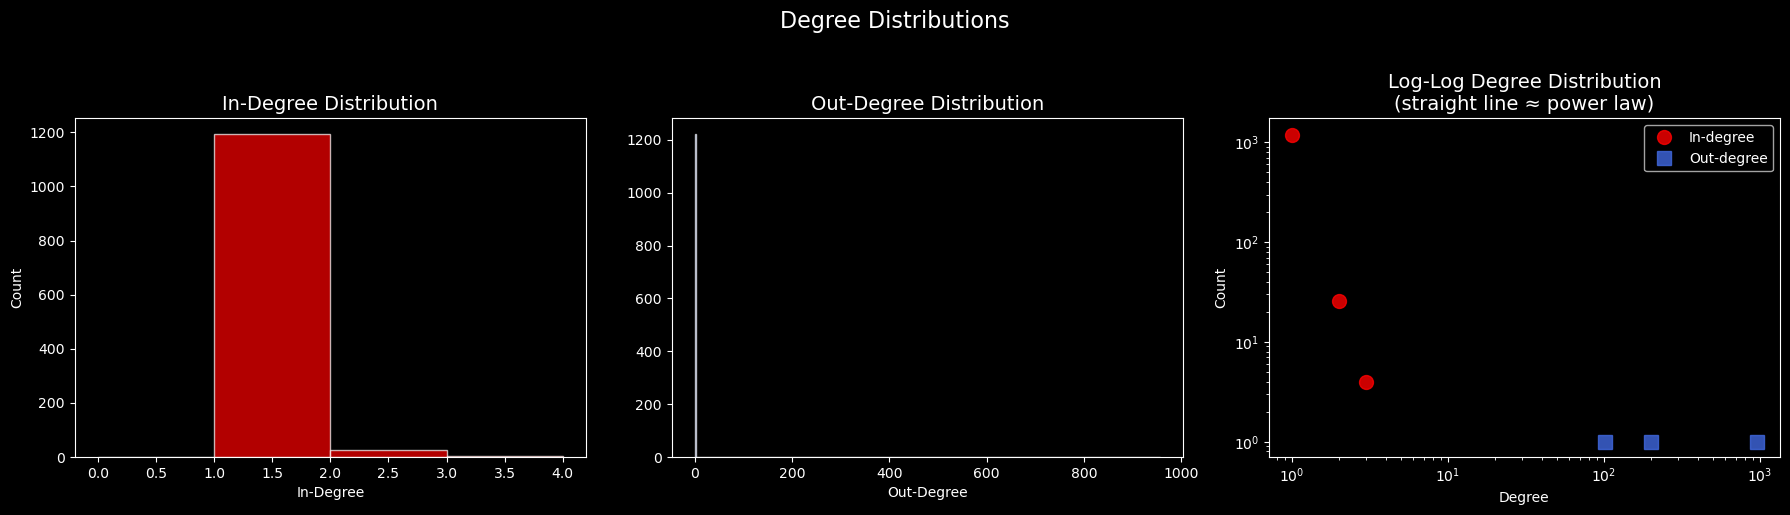


TOP 10 NODES BY DEGREE
                 Top In-Degree                    Top Out-Degree
         ISSN (identifier) (3)            Machine learning (955)
         ISBN (identifier) (3)              Live streaming (200)
          Doi (identifier) (3)            Social computing (101)
        S2CID (identifier) (3)                 Livestreaming (0)
                Video game (2) Syntactic pattern recognition (0)
               Game theory (2)               Graphical model (0)
           Online streamer (2)                SAS (software) (0)
Human–computer interaction (2)         Polynomial regression (0)
          Computer science (2)                      17 (app) (0)
          Hdl (identifier) (2)      Lethal autonomous weapon (0)

COMPUTING CENTRALITY MEASURES...

Top 15 by PageRank:
                            PR Rank  Btw Rank  Eig Rank  InDeg Rank
Doi (identifier)                  2       613         2           2
ISBN (identifier)                 2       613         2           2
IS

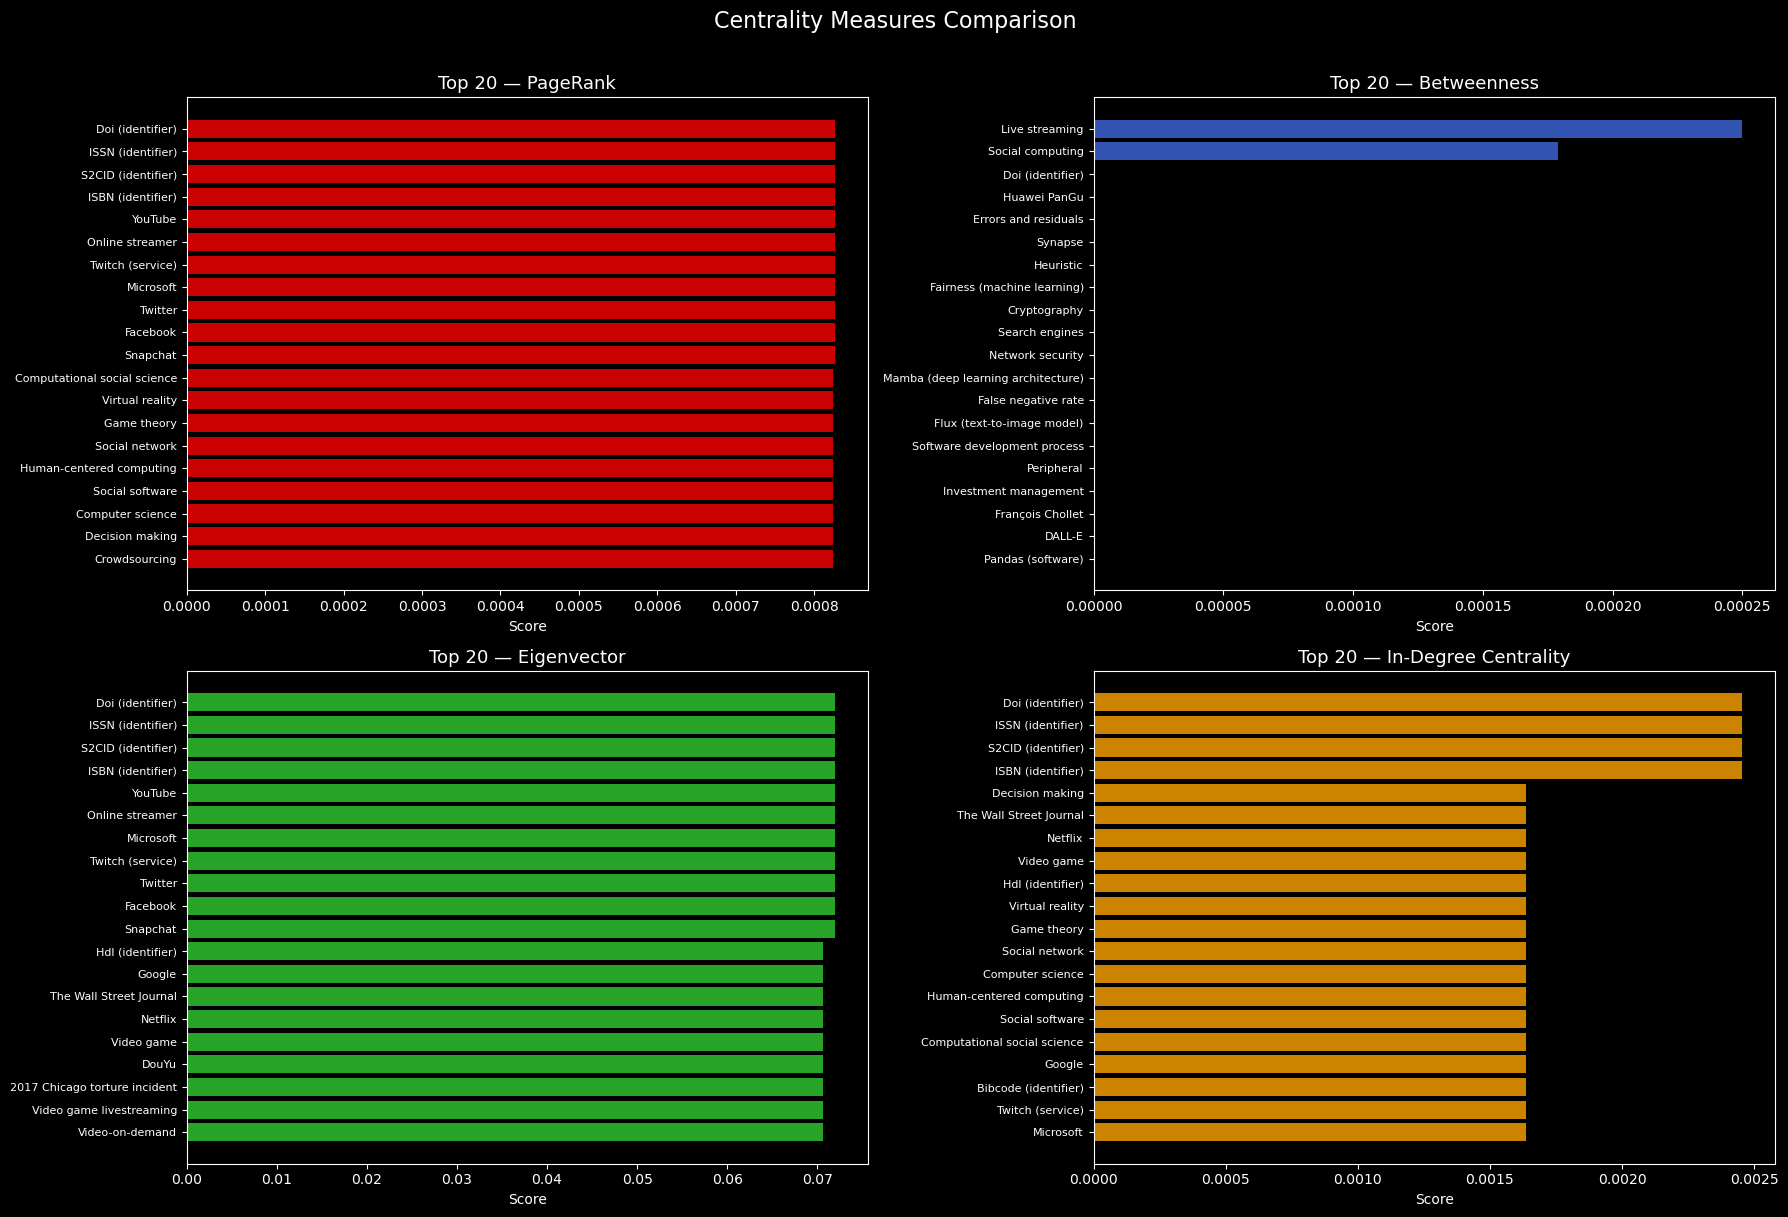

In [6]:
# ── Analysis ──────────────────────────────────────────────────────────────────

print("=" * 50)
print("BASIC GRAPH STATISTICS")
print("=" * 50)
print(f"Nodes:               {G.number_of_nodes()}")
print(f"Edges:               {G.number_of_edges()}")
print(f"Density:             {nx.density(G):.6f}")
print(f"Avg clustering coef: {nx.average_clustering(G):.4f}")

print(f"\nStrongly connected:  {nx.is_strongly_connected(G)}")
print(f"Weakly connected:    {nx.is_weakly_connected(G)}")
print(f"# strong components: {nx.number_strongly_connected_components(G)}")
print(f"# weak components:   {nx.number_weakly_connected_components(G)}")

largest_wcc = G.subgraph(max(nx.weakly_connected_components(G),   key=len)).copy()
largest_scc = G.subgraph(max(nx.strongly_connected_components(G), key=len)).copy()
print(f"\nLargest WCC — nodes: {largest_wcc.number_of_nodes()}, edges: {largest_wcc.number_of_edges()}")
print(f"Largest SCC — nodes: {largest_scc.number_of_nodes()}, edges: {largest_scc.number_of_edges()}")
print(f"Diameter (WCC undirected): {nx.diameter(largest_wcc.to_undirected())}")

# ── Degree distribution ───────────────────────────────────────────────────────
in_degrees  = [d for _, d in G.in_degree()]
out_degrees = [d for _, d in G.out_degree()]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(in_degrees,  bins=range(min(in_degrees),  max(in_degrees)  + 2),
             color="red",       alpha=0.7, edgecolor="white")
axes[0].set_title("In-Degree Distribution",  fontsize=14)
axes[0].set_xlabel("In-Degree"); axes[0].set_ylabel("Count")

axes[1].hist(out_degrees, bins=range(min(out_degrees), max(out_degrees) + 2),
             color="royalblue", alpha=0.7, edgecolor="white")
axes[1].set_title("Out-Degree Distribution", fontsize=14)
axes[1].set_xlabel("Out-Degree")

in_deg_counts  = np.bincount(in_degrees)
out_deg_counts = np.bincount(out_degrees)
axes[2].loglog(np.nonzero(in_deg_counts)[0],  in_deg_counts[in_deg_counts > 0],
               "o", color="red",       alpha=0.8, markersize=10, label="In-degree")
axes[2].loglog(np.nonzero(out_deg_counts)[0], out_deg_counts[out_deg_counts > 0],
               "s", color="royalblue", alpha=0.8, markersize=10, label="Out-degree")
axes[2].set_title("Log-Log Degree Distribution\n(straight line ≈ power law)", fontsize=14)
axes[2].set_xlabel("Degree"); axes[2].set_ylabel("Count"); axes[2].legend()

plt.suptitle("Degree Distributions", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# ── Top nodes ─────────────────────────────────────────────────────────────────
print("\n" + "=" * 50)
print("TOP 10 NODES BY DEGREE")
print("=" * 50)

top_in  = sorted(G.in_degree(),  key=lambda x: x[1], reverse=True)[:10]
top_out = sorted(G.out_degree(), key=lambda x: x[1], reverse=True)[:10]
df_top  = pd.DataFrame({
    "Top In-Degree":  [f"{n} ({d})" for n, d in top_in],
    "Top Out-Degree": [f"{n} ({d})" for n, d in top_out],
})
print(df_top.to_string(index=False))

# ── Centrality ────────────────────────────────────────────────────────────────
print("\n" + "=" * 50)
print("COMPUTING CENTRALITY MEASURES...")
print("=" * 50)

pagerank    = nx.pagerank(G)
betweenness = nx.betweenness_centrality(G)
eigenvector = nx.eigenvector_centrality(G, max_iter=500)
in_cent     = nx.in_degree_centrality(G)

df_cent = pd.DataFrame({
    "pagerank":    pagerank,
    "betweenness": betweenness,
    "eigenvector": eigenvector,
    "in_degree":   in_cent,
})
for col in df_cent.columns:
    df_cent[f"{col}_rank"] = df_cent[col].rank(ascending=False).astype(int)

df_cent   = df_cent.sort_values("pagerank", ascending=False)
rank_cols = ["pagerank_rank", "betweenness_rank", "eigenvector_rank", "in_degree_rank"]

print("\nTop 15 by PageRank:")
print(df_cent[rank_cols].head(15).rename(columns={
    "pagerank_rank":    "PR Rank",
    "betweenness_rank": "Btw Rank",
    "eigenvector_rank": "Eig Rank",
    "in_degree_rank":   "InDeg Rank",
}).to_string())

# ── Centrality comparison plot ────────────────────────────────────────────────
top_n  = 20
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
metrics = [
    ("pagerank",    "PageRank",             "red"),
    ("betweenness", "Betweenness",          "royalblue"),
    ("eigenvector", "Eigenvector",          "limegreen"),
    ("in_degree",   "In-Degree Centrality", "orange"),
]
for ax, (col, title, color) in zip(axes.flat, metrics):
    data = df_cent[col].sort_values(ascending=False).head(top_n)
    ax.barh(data.index[::-1], data.values[::-1], color=color, alpha=0.8)
    ax.set_title(f"Top {top_n} — {title}", fontsize=13)
    ax.set_xlabel("Score")
    ax.tick_params(axis="y", labelsize=8)

plt.suptitle("Centrality Measures Comparison", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()